In [296]:
import pandas as pd
flights = pd.read_csv("/Users/aditya/development/flight-delay-prediction/data/raw/flights.csv",nrows=100000)

flights.shape
flights.columns
flights.head(20)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,2015,1,1,4,DL,806,N3730B,SFO,MSP,25,...,610.0,8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
6,2015,1,1,4,NK,612,N635NK,LAS,MSP,25,...,509.0,-17.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
7,2015,1,1,4,US,2013,N584UW,LAX,CLT,30,...,753.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
8,2015,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,...,532.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
9,2015,1,1,4,DL,1173,N826DN,LAS,ATL,30,...,656.0,-15.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [297]:
#How many flights does each airline have in our sample?
flights['AIRLINE'].value_counts()

AIRLINE
WN    21160
DL    13156
EV    10810
OO    10475
AA     9449
UA     8413
US     6968
MQ     6305
B6     4688
AS     2836
NK     1813
F9     1563
HA     1328
VX     1036
Name: count, dtype: int64

In [298]:
#How many unique origin airports are in our sample?
flights['ORIGIN_AIRPORT'].nunique()

312

In [299]:
#How many unique destination airports are in our sample?
flights["DESTINATION_AIRPORT"].nunique()

312

In [300]:
#find null values 
flights.isnull().sum().sort_values(ascending=False)


CANCELLATION_REASON    97611
WEATHER_DELAY          65375
LATE_AIRCRAFT_DELAY    65375
AIRLINE_DELAY          65375
SECURITY_DELAY         65375
AIR_SYSTEM_DELAY       65375
AIR_TIME                2613
ARRIVAL_DELAY           2613
ELAPSED_TIME            2613
WHEELS_ON               2440
TAXI_IN                 2440
ARRIVAL_TIME            2440
TAXI_OUT                2371
WHEELS_OFF              2371
DEPARTURE_DELAY         2298
DEPARTURE_TIME          2298
TAIL_NUMBER              167
SCHEDULED_DEPARTURE        0
CANCELLED                  0
DAY                        0
DAY_OF_WEEK                0
AIRLINE                    0
FLIGHT_NUMBER              0
SCHEDULED_ARRIVAL          0
DIVERTED                   0
ORIGIN_AIRPORT             0
DISTANCE                   0
DESTINATION_AIRPORT        0
MONTH                      0
SCHEDULED_TIME             0
YEAR                       0
dtype: int64

In [301]:
#Our eventual prediction target is based on arrival delay, so we need to understand this column
flights['ARRIVAL_DELAY'].describe()

count    97387.000000
mean        18.342304
std         48.878234
min        -65.000000
25%         -8.000000
50%          4.000000
75%         27.000000
max       1384.000000
Name: ARRIVAL_DELAY, dtype: float64

In [302]:
flights['ARRIVAL_DELAY'].value_counts().head(20)

ARRIVAL_DELAY
-6.0     2233
-5.0     2173
-2.0     2150
-4.0     2125
-3.0     2124
-8.0     2123
-7.0     2121
-1.0     2116
-9.0     2068
-10.0    2031
 0.0     2000
-12.0    1911
 1.0     1886
-11.0    1858
 2.0     1810
-13.0    1727
 3.0     1719
 4.0     1706
 5.0     1654
-14.0    1614
Name: count, dtype: int64

In [425]:
#How many flights were delayed by 15 minutes or more?
delayed_flights= flights[flights["ARRIVAL_DELAY"] >= 15]
delayed_flights.head(20)
delayed_flights.shape #34625,31
flights.shape # 100000,31
delayed_flights.head(20)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
27,2015,1,1,4,NK,597,N528NK,MSP,FLL,115,...,607.0,25.0,0,0,NaN,25.0,0.0,0.0,0.0,0.0
30,2015,1,1,4,NK,168,N629NK,PHX,ORD,125,...,632.0,43.0,0,0,NaN,43.0,0.0,0.0,0.0,0.0
35,2015,1,1,4,HA,17,N389HA,LAS,HNL,145,...,610.0,15.0,0,0,NaN,0.0,0.0,15.0,0.0,0.0
50,2015,1,1,4,B6,1030,N239JB,BQN,MCO,307,...,520.0,20.0,0,0,NaN,20.0,0.0,0.0,0.0,0.0
52,2015,1,1,4,B6,2134,N307JB,SJU,MCO,400,...,730.0,85.0,0,0,NaN,0.0,0.0,85.0,0.0,0.0
55,2015,1,1,4,B6,2276,N646JB,SJU,BDL,438,...,908.0,89.0,0,0,NaN,17.0,0.0,72.0,0.0,0.0
70,2015,1,1,4,AA,1057,N3ASAA,DFW,MIA,515,...,1038.0,102.0,0,0,NaN,0.0,0.0,0.0,0.0,102.0
73,2015,1,1,4,US,425,N174US,PDX,PHX,520,...,950.0,60.0,0,0,NaN,0.0,0.0,60.0,0.0,0.0
74,2015,1,1,4,AA,89,N3KVAA,IAH,MIA,520,...,935.0,54.0,0,0,NaN,0.0,0.0,54.0,0.0,0.0
86,2015,1,1,4,AA,328,N4XKAA,DEN,DFW,530,...,941.0,66.0,0,0,NaN,13.0,0.0,53.0,0.0,0.0


In [304]:
#calculate delay rate.. (no of delayed flights/total flights)*100

delay_rate = (delayed_flights.shape[0] / flights.shape[0]) * 100
delay_rate




34.625

flights['ARRIVAL_DELAY'].isnull().sum() #2613
This uses 100,000 as the denominator.
That's okay as a quick overall statistic, 
but because 2,613 flights have no ARRIVAL_DELAY, 
we should also calculate the rate among flights where arrival delay is actually known.

In [305]:

valid_arrival_delay = flights["ARRIVAL_DELAY"].notna()
flights_with_delay = flights[valid_arrival_delay]#fligts_with_delay = flights[flights["ARRIVAL_DELAY"].notna()]
flights_with_delay.shape #(97387, 31) 1000000 - 2613


delay_rate = (
    (flights_with_delay["ARRIVAL_DELAY"] >= 15).sum()
    / len(flights_with_delay)
) * 100

delay_rate
# (flights_with_delay["ARRIVAL_DELAY"]>=15)

np.float64(35.55402671814513)

That's our overall delay rate for this sample.
Now let's ask a better question
Overall delay rate is useful, but for our project we want:
Does the delay rate differ between airlines?
For example, conceptually:
Airline     Flights    Delayed    Delay Rate
AA          9,000       2,500       27.8%
DL          13,000      3,000       23.1%
WN          21,000      5,500       26.2%

In [306]:
# now lets create is_delayed
flights_with_delay['is_delayed']= flights_with_delay['ARRIVAL_DELAY'] >=15
flights_with_delay[['is_delayed','ARRIVAL_DELAY','AIRLINE']].head(5)




,is_delayed,ARRIVAL_DELAY,AIRLINE
0,False,-22.0,AS
1,False,-9.0,AA
2,False,5.0,US
3,False,-9.0,AA
4,False,-21.0,AS


In [307]:
# Now introduce groupby()
flights_with_delay.groupby("AIRLINE")['is_delayed'].sum()
flights_with_delay.groupby("AIRLINE")['FLIGHT_NUMBER'].count()

#create a table 
airline_delay = flights_with_delay.groupby("AIRLINE").agg(
    total_flights=("FLIGHT_NUMBER","count"),
    delayed_flights=("is_delayed","sum")
)
airline_delay

# #calculate delay rate

airline_delay["delay_rate"] = (airline_delay["delayed_flights"]/ airline_delay["total_flights"])*100
airline_delay

,total_flights,delayed_flights,delay_rate
AIRLINE,,,
AA,9176,3784,41.238012
AS,2829,559,19.759632
B6,4658,1624,34.864749
DL,13125,2650,20.190476
EV,10345,3956,38.240696
F9,1518,761,50.131752
HA,1325,335,25.283019
MQ,5415,3132,57.839335
NK,1791,825,46.063652


In [308]:
#sort the table
airline_delay.sort_values('delay_rate',ascending=False)

,total_flights,delayed_flights,delay_rate
AIRLINE,,,
MQ,5415,3132,57.839335
F9,1518,761,50.131752
NK,1791,825,46.063652
AA,9176,3784,41.238012
WN,20923,8178,39.086173
EV,10345,3956,38.240696
UA,8328,3108,37.319885
OO,10030,3589,35.782652
B6,4658,1624,34.864749


Important
Don't interpret this as "MQ is the worst airline." This is only an observed delay rate in our 100,000-row sample, and we haven't accounted for factors such as airport, route, time, weather, etc.
That's exactly why we're doing analytics before jumping to conclusions.

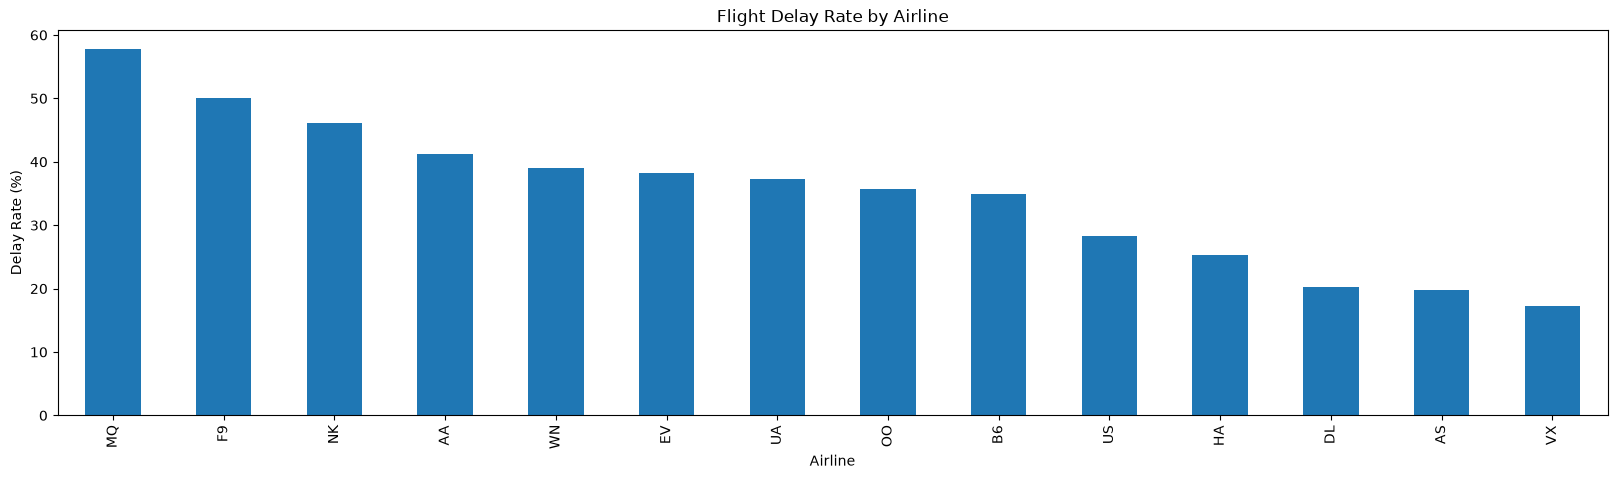

In [309]:
import matplotlib.pyplot as plt

airline_delay["delay_rate"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(20, 5)
)

plt.title("Flight Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay Rate (%)")
plt.show()

We've already done:
Airline → total flights → delayed flights → delay rate
Now we're going to do the same thing for airports.
Our question is:
How does the delay rate vary by origin airport?

In [310]:
flights
flights_with_delay.head()
airport_delay = flights_with_delay.groupby('ORIGIN_AIRPORT').agg(
    total_flights=('FLIGHT_NUMBER','count'),
    delayed_flights=('is_delayed','sum')

)
airport_delay['delay_rate'] = (airport_delay['delayed_flights']/ airport_delay['total_flights']) *100

airport_delay.sort_values('delayed_flights',ascending=False)

,total_flights,delayed_flights,delay_rate
ORIGIN_AIRPORT,,,
ORD,4562,2459,53.901797
DFW,4572,2307,50.459318
DEN,3766,2138,56.771110
ATL,5958,1461,24.521652
LAX,3732,1276,34.190782
...,...,...,...
EKO,16,0,0.000000
GFK,4,0,0.000000
BET,15,0,0.000000


BUT ⚠️ don't interpret this yet.
You might see something like:
Airport X     3 flights      3 delayed      100%
Airport Y     5 flights      4 delayed       80%
Airport Z   5000 flights   2000 delayed       40%
If we simply rank by delay_rate, Airport X would appear first.
But 3 flights isn't enough evidence to meaningfully compare an airport with 5,000 flights.
This is called the small-sample problem.

for the airports at the top.
ask yourself:
Are these airports actually handling a meaningful number of flights?

Set a minimum flight threshold
For our analysis, let's only consider airports with at least 500 flights in our sample.
This isn't a universal rule — we're choosing it for this analysis so extremely small samples don't dominate the ranking.

In [311]:
airport_delay_filtered = airport_delay[airport_delay['total_flights'] >=500]
airport_delay_filtered.sort_values("delay_rate",ascending=False).head(10)
# airport_delay_filtered.shape


,total_flights,delayed_flights,delay_rate
ORIGIN_AIRPORT,,,
DEN,3766,2138,56.771110
ORD,4562,2459,53.901797
MDW,1417,736,51.940720
DFW,4572,2307,50.459318
MKE,520,246,47.307692
PHL,1147,536,46.730602
EWR,1807,812,44.936359
IAD,875,379,43.314286
BWI,1483,641,43.223196


Does departure time affect delays? 
This is an important question for airport operations:
Are flights scheduled at certain times more likely to be delayed?

In [312]:
flights_with_delay['departure_hour'] = (flights_with_delay['SCHEDULED_DEPARTURE']//100 )
flights_with_delay.head(10)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,is_delayed,departure_hour
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0
5,2015,1,1,4,DL,806,N3730B,SFO,MSP,25,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0
6,2015,1,1,4,NK,612,N635NK,LAS,MSP,25,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0
7,2015,1,1,4,US,2013,N584UW,LAX,CLT,30,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0
8,2015,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0
9,2015,1,1,4,DL,1173,N826DN,LAS,ATL,30,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0


Now we can ask:
How many flights operate in each hour?

In [313]:
flights_with_delay.groupby('departure_hour')['FLIGHT_NUMBER'].count()

departure_hour
0      245
1      174
2       54
3       19
4       31
5     1419
6     7478
7     6777
8     7274
9     6486
10    6769
11    6077
12    5472
13    6055
14    5560
15    5688
16    5456
17    6269
18    5306
19    5400
20    4061
21    3063
22    1500
23     754
Name: FLIGHT_NUMBER, dtype: int64

This tells us the number of flights scheduled in each hour.
But that's not what we ultimately want.
Calculate delay rate by hour

In [314]:
hourly_delay = flights_with_delay.groupby('departure_hour').agg(
    total_flights=('FLIGHT_NUMBER','count'),
    delayed_flights=('is_delayed','sum') 

)

hourly_delay['delay_rate'] = (hourly_delay['delayed_flights']/hourly_delay['total_flights'])*100
hourly_delay


,total_flights,delayed_flights,delay_rate
departure_hour,,,
0,245,53,21.632653
1,174,58,33.333333
2,54,14,25.925926
3,19,9,47.368421
4,31,10,32.258065
5,1419,241,16.983791
6,7478,1428,19.096015
7,6777,1444,21.307363
8,7274,1875,25.776739


You can see a general pattern:
Early morning around 5–7 AM has relatively lower observed delay rates.
Delay rates generally increase through the day.
Evening hours around 18–21 have relatively high observed delay rates.
There is a weird spike at 3 AM.
But look back at your table:
3 AM → 19 flights → 9 delayed → 47.37%
Only 19 flights!
That's why we shouldn't immediately conclude:
"3 AM flights are highly delayed."
There simply aren't enough observations in our sample.

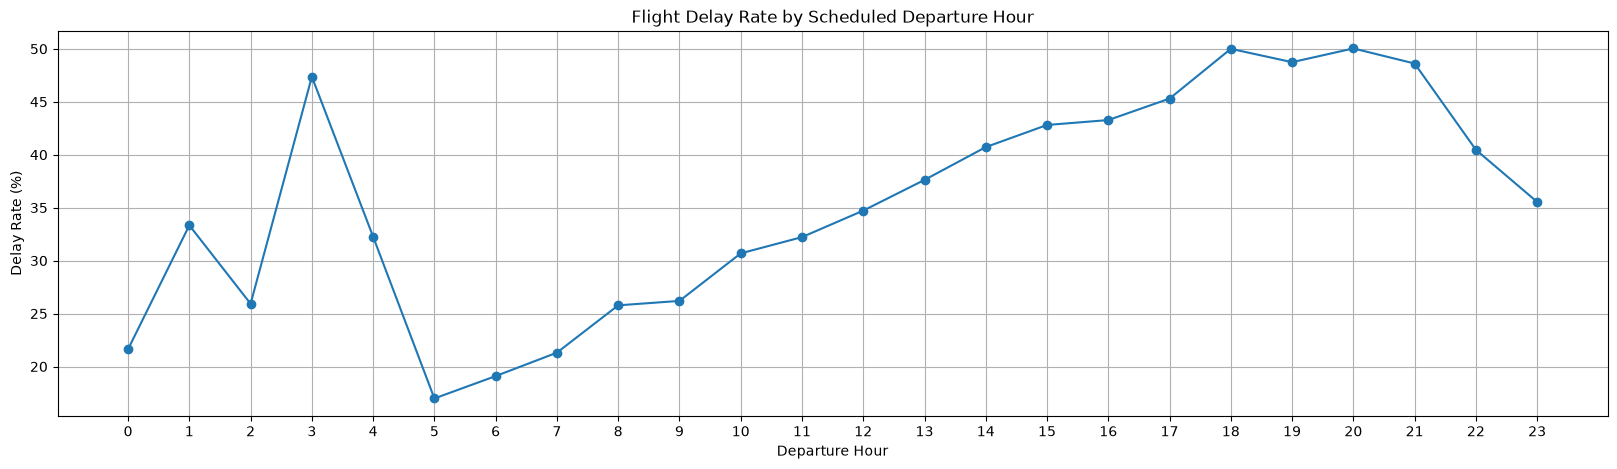

In [315]:
import matplotlib.pyplot as plt
import importlib

importlib.reload(plt)
hourly_delay["delay_rate"].plot(
    kind="line",
    figsize=(20, 5),
    marker="o"
)


plt.title("Flight Delay Rate by Scheduled Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Delay Rate (%)")
plt.xticks(range(24))
plt.grid()
plt.show()

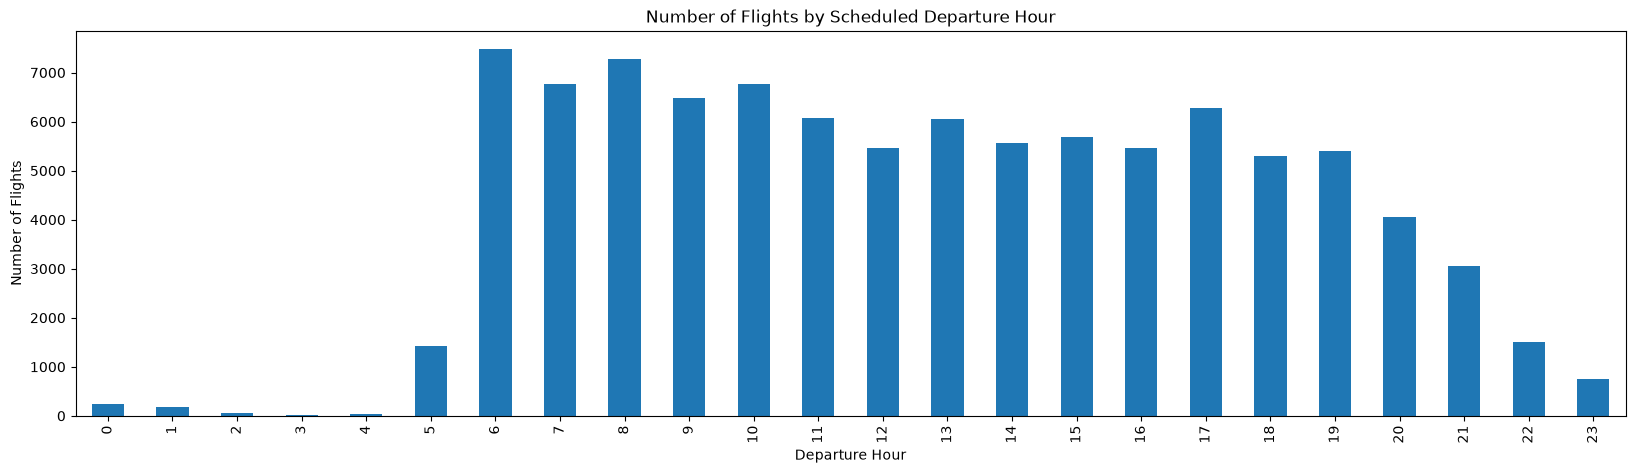

In [316]:
hourly_delay["total_flights"].plot(
    kind="bar",
    figsize=(20, 5)
)

plt.title("Number of Flights by Scheduled Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Number of Flights")
plt.xticks(range(24))
plt.show()

In [317]:
hourly_delay_filtered = hourly_delay[hourly_delay['total_flights']>=500]
hourly_delay_filtered

,total_flights,delayed_flights,delay_rate
departure_hour,,,
5,1419,241,16.983791
6,7478,1428,19.096015
7,6777,1444,21.307363
8,7274,1875,25.776739
9,6486,1699,26.194881
10,6769,2077,30.684001
11,6077,1958,32.219845
12,5472,1900,34.722222
13,6055,2278,37.621800


Our next question:
Does the delay rate change depending on the day of the week?

In [318]:
flights_with_delay.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,is_delayed,departure_hour
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,0


In [319]:
day_delay = flights_with_delay.groupby("DAY_OF_WEEK").agg(
    total_flights=('FLIGHT_NUMBER','count'),
    delayed_flights=('is_delayed','sum')



)


day_delay['delay_rate'] = (day_delay['delayed_flights'] / day_delay['total_flights'])*100
day_delay

,total_flights,delayed_flights,delay_rate
DAY_OF_WEEK,,,
1,16074,5634,35.050392
2,14876,5515,37.073138
3,5580,1283,22.992832
4,13464,2987,22.185086
5,16456,4568,27.758872
6,15050,6805,45.215947
7,15887,7833,49.304463


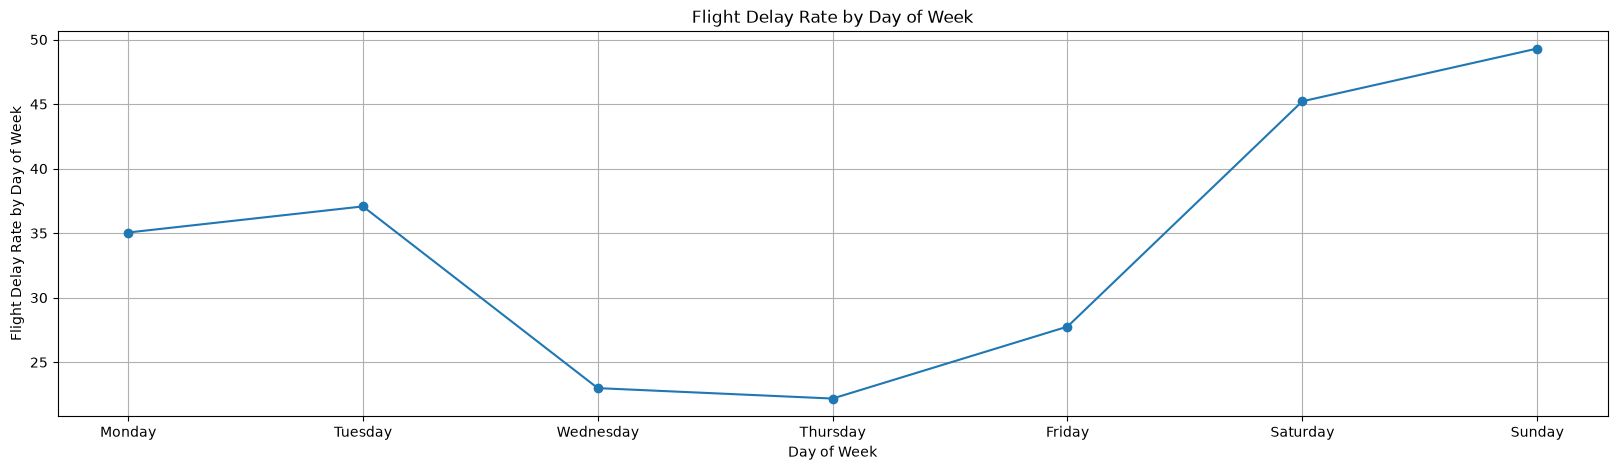

In [320]:
import matplotlib.pyplot as plt
day_delay['delay_rate'].plot(kind='line',figsize=(20,5),marker="o")
plt.title("Flight Delay Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Flight Delay Rate by Day of Week")

plt.grid()

plt.xticks(
    range(1,8),
    ["Monday", "Tuesday", "Wednesday", "Thursday",
     "Friday", "Saturday", "Sunday"],
    
)
plt.show()



What exactly are we predicting?
Our project is called:
Flight Delay Prediction and Airport Operational Analytics
We need to define the thing our ML model will predict.


We already created:
"is_delayed"
based on:
ARRIVAL_DELAY >= 15
So our target is:
"is_delayed"
    ↓
0 = Not delayed
1 = Delayed

In [321]:
flights_with_delay["is_delayed"].value_counts()

is_delayed
False    62762
True     34625
Name: count, dtype: int64

In [322]:
flights_with_delay["is_delayed"].value_counts(normalize=True) *100

is_delayed
False    64.445973
True     35.554027
Name: proportion, dtype: float64

value_counts()
       ↓
HOW MANY?

value_counts(normalize=True)
       ↓
WHAT PROPORTION?

value_counts(normalize=True) * 100
       ↓
WHAT PERCENTAGE?

For our project
Let's make our first model a:
Pre-departure flight delay prediction model
Meaning:
          BEFORE FLIGHT
               ↓
        Gather information
               ↓
        Predict delay
               ↓
       Delayed / Not delayed
Therefore we'll focus on information known before departure.
Good candidate features include things like:
MONTH
DAY
DAY_OF_WEEK
AIRLINE
ORIGIN_AIRPORT
DESTINATION_AIRPORT
SCHEDULED_DEPARTURE
SCHEDULED_ARRIVAL
SCHEDULED_TIME
DISTANCE

While things such as:
ARRIVAL_DELAY
ARRIVAL_TIME
WHEELS_ON
TAXI_IN
are unavailable at prediction time.


Now we're going to create our feature list.
Think of machine learning like this:
                 FEATURES
                    ↓
        ┌─────────────────────┐
        │    ML MODEL         │
        └─────────────────────┘
                    ↓
               PREDICTION
                    ↓
              is_delayed
The features are the information we give the model.
For example:
Airline = AA
Origin = LAX
Destination = JFK
Departure hour = 14
Distance = 2475 miles
Day = Monday
The model uses these to estimate whether the flight will be delayed.

In [327]:
features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE",
    "SCHEDULED_ARRIVAL",
    "SCHEDULED_TIME",
    "DISTANCE"
]
target = "is_delayed"

We won't use:
ARRIVAL_DELAY
ARRIVAL_TIME
WHEELS_ON
TAXI_IN
because these happen after the flight is underway or completed.
And importantly:
DEPARTURE_DELAY
is also not included in our first model.
Why?
Because we're defining this as a pre-departure prediction.
At the moment we're making the prediction, the actual departure delay isn't known yet.

Create our ML dataset
Now let's make a new DataFrame containing only the information we want.

In [328]:
model_data = flights_with_delay[features + [target]]
model_data.isnull().sum()

model_data.dtypes

MONTH                  int64
DAY                    int64
DAY_OF_WEEK            int64
AIRLINE                  str
ORIGIN_AIRPORT           str
DESTINATION_AIRPORT      str
SCHEDULED_DEPARTURE    int64
SCHEDULED_ARRIVAL      int64
SCHEDULED_TIME         int64
DISTANCE               int64
is_delayed              bool
dtype: object

Notice these:
AIRLINE                  str
ORIGIN_AIRPORT           str
DESTINATION_AIRPORT      str

That means they contain text/category values, such as:
AIRLINE

AA
DL
UA
WN
...
A machine-learning model can't directly perform mathematical calculations on "AA" or "LAX".
So we need to convert those categories into numbers.

In [329]:
print(model_data.head(4))
print(model_data.shape)
model_data.dtypes

   MONTH  DAY  DAY_OF_WEEK AIRLINE ORIGIN_AIRPORT DESTINATION_AIRPORT  \
0      1    1            4      AS            ANC                 SEA   
1      1    1            4      AA            LAX                 PBI   
2      1    1            4      US            SFO                 CLT   
3      1    1            4      AA            LAX                 MIA   

   SCHEDULED_DEPARTURE  SCHEDULED_ARRIVAL  SCHEDULED_TIME  DISTANCE  \
0                    5                430             205      1448   
1                   10                750             280      2330   
2                   20                806             286      2296   
3                   20                805             285      2342   

   is_delayed  
0       False  
1       False  
2       False  
3       False  
(97387, 11)


MONTH                  int64
DAY                    int64
DAY_OF_WEEK            int64
AIRLINE                  str
ORIGIN_AIRPORT           str
DESTINATION_AIRPORT      str
SCHEDULED_DEPARTURE    int64
SCHEDULED_ARRIVAL      int64
SCHEDULED_TIME         int64
DISTANCE               int64
is_delayed              bool
dtype: object

Now: Why can't the model use "AA" or "LAX"?
Imagine we give a model:
AIRLINE
AA
DL
WN
UA
A machine-learning model works mathematically with numbers.
It can't naturally calculate something meaningful like:
AA + DL
😂
So we need to convert categories into numerical columns.
This is called One-Hot Encoding.

Why NOT simply assign numbers?
You might think:
AA → 1
DL → 2
WN → 3
UA → 4
But there's a problem.
The model could interpret this as:
WN (3) > DL (2) > AA (1)
It might think airline 3 is somehow "greater" than airline 2.
But airline codes have no numerical order.
So instead we use:

One-Hot Encoding
Suppose we have:
AIRLINE
AA
DL
WN
We turn it into:
AA   DL   WN
1    0    0
0    1    0
0    0    1
Now each airline gets its own column.
No fake ordering.

AIRLINE
ORIGIN_AIRPORT
DESTINATION_AIRPORT
These are the columns we'll encode.

Separate features and target
Now we're going to create two DataFrames.
Features
X = model_data[features]
X means:
The information we're giving to the model.
Target
y = model_data[target]
y means:
The answer we're asking the model to predict.
So:
X                              y
──────────────────────         ──────────
MONTH                          is_delayed
DAY
DAY_OF_WEEK
AIRLINE
ORIGIN_AIRPORT
DESTINATION_AIRPORT
...
DISTANCE
Think of it like an exam:
X = questions / information
y = answers
The model learns the relationship between them.

In [336]:
X = model_data[features]
y = model_data[target]


y.head(8)

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
Name: is_delayed, dtype: bool

In [331]:
X.head(6)



,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,SCHEDULED_TIME,DISTANCE
0,1,1,4,AS,ANC,SEA,5,430,205,1448
1,1,1,4,AA,LAX,PBI,10,750,280,2330
2,1,1,4,US,SFO,CLT,20,806,286,2296
3,1,1,4,AA,LAX,MIA,20,805,285,2342
4,1,1,4,AS,SEA,ANC,25,320,235,1448
5,1,1,4,DL,SFO,MSP,25,602,217,1589


encolding using scikit 

In [332]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT"
]

numerical_features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "SCHEDULED_DEPARTURE",
    "SCHEDULED_ARRIVAL",
    "SCHEDULED_TIME",
    "DISTANCE"
]

encoder = OneHotEncoder(handle_unknown="ignore") #handle_unknown="ignore" 
# tells it: "If you encounter a category you haven't seen before, don't throw an error.
# "This is useful when we eventually split our data into training and testing sets.

encoder.fit(X[categorical_features])
encoder.categories_ 

X_encoded = encoder.transform(X[categorical_features])
X_encoded.shape

(97387, 638)

Right now:
X
contains:
numeric columns + categorical text columns
while:
X_encoded
contains:
one-hot encoded categorical columns
But our model needs both.
We eventually need:
                    X
                    │
          ┌─────────┴─────────┐
          ↓                   ↓
   Numerical columns     Categorical
          │                   │
      keep them          One-hot encode
          │                   │
          └─────────┬─────────┘
                    ↓
             Combine together
                    ↓
              Final X
We'll do that next.

But there's an important ML issue first ⚠️
We've currently done:
encoder.fit(X[categorical_features])
on all 97,387 rows.
For learning the concept, that's okay.
But when we build the actual model, we shouldn't do this.
We need to first split our data:
97,387 flights
       ↓
 ┌──────────────┐
 │ Training     │
 │ ~80%         │
 └──────────────┘
       +
 ┌──────────────┐
 │ Testing      │
 │ ~20%         │
 └──────────────┘
Then:
Training data
      ↓
fit encoder
      ↓
learn categories
      ↓
transform training data

Testing data
      ↓
transform using SAME encoder
This prevents data leakage.
So we're going to slightly change our approach now rather than continuing with the encoder fitted on the whole dataset.

Why split before encoding?
We split the data into training and test sets before fitting the encoder to prevent data leakage, which means accidentally allowing information from the test data to influence the learning process. The encoder should learn the categories only from the training data because the test data is supposed to represent unseen, real-world data. We then use the same learned encoder to transform both the training and test data—we do not fit a new encoder on the test data, because that would allow the test set to influence preprocessing. For example, in an exam, you study the syllabus before the exam (training data) and learn your concepts from it; you don't look at the actual exam paper to learn new concepts before taking it (test data). Similarly, the encoder learns from X_train and then simply applies those learned rules to X_test.

The principle in machine learning is:
__Anything that learns from the dataset should learn only from the training set.__

In [351]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    
    random_state=42,
    stratify=y
)

X_train.shape
X_test.shape
y_train.shape
y_test.shape

#create encoder 





,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequen

**test_size** specifies the proportion or number of samples reserved for testing the model. For example, test_size=0.2 reserves 20% of the data for testing and uses the remaining 80% for training. It can be given as a decimal proportion (0.2 = 20%) or as an integer number of samples.

**random_state** is a seed that controls the randomness of the train/test split. It does not specify the number of samples or percentage. Using the same integer, such as 42, produces the same random split every time, while changing the integer produces a different split. The value 42 is arbitrary and commonly used as a convention.

**random_state** is a seed that controls the randomness of the train/test split. It does not specify the number of samples or percentage. Using the same integer, such as 42, produces the same random split every time, while changing the integer produces a different split. The value 42 is arbitrary and commonly used as a convention.

Take our input features X and target y, randomly split them into 80% training and 20% testing, use 42 as a fixed seed so that the random split is reproducible, and preserve the proportion of delayed and non-delayed flights in both sets.


In [370]:
encoder.fit(X_train[categorical_features])
encoder.categories_
# fit = LEARN
categorical_features
X_train[categorical_features].columns

#transform the train data set
X_train_encoded =encoder.transform(
    X_train[categorical_features]
    )

#transform the test data set
X_test_encoded = encoder.transform(
    X_test[categorical_features]
)

print(X_train_encoded.shape,
X_test_encoded.shape)



(77909, 636) (19478, 636)


TRAINING DATA
     ↓
encoder.fit()
     ↓
learn categories
     ↓
encoder.transform()
     ↓
X_train_encoded


TEST DATA
     ↓
same encoder
     ↓
encoder.transform()
     ↓
X_test_encoded

X contains the input features used by the model, while y contains the target/answer the model is trying to predict. We separate them so the model knows which variables are inputs and which variable is the target. We then split both X and y into training and testing sets. X_train and y_train are used to train the model, while X_test is used to make predictions and y_test contains the actual answers used to evaluate those predictions.

In [373]:
X_train_encoded[:10].toarray()

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 30 stored elements and shape (10, 636)>

Now we need to combine the encoded categorical features with the numerical features.
Combine them Because X_train_encoded is a sparse matrix, we'll use hstack from SciPy to put the columns side-by-side.

In [374]:
from scipy.sparse import hstack

X_train_numeric = X_train[numerical_features]
X_test_numeric = X_test[numerical_features]

X_train_final = hstack([
    X_train_encoded,
    X_train_numeric
])

X_test_final = hstack([
    X_test_encoded,
    X_test_numeric
])

In [388]:
X_train_final.shape # 77,909 flights × 643 features → training
X_test_final.shape # 19,478 flights × 643 features → testing 

print(y_train.value_counts())
y_train.value_counts(normalize=True) * 100

#The first tells us the number of each class.
# The second tells us the percentage of each class.

is_delayed
False    50209
True     27700
Name: count, dtype: int64


is_delayed
False    64.445699
True     35.554301
Name: proportion, dtype: float64

We have finished the preprocessing, so now we're ready for our first ML model.
Our first model: __Logistic Regression__
We're going to start with Logistic Regression.
Don't let the word "Regression" confuse you. Despite its name, Logistic Regression is commonly used for classification.

In [389]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_final,
    y_train


)

/Users/aditya/development/flight-delay-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

We told it:
max_iter=1000
meaning:
"You can try at most 1,000 times."
It reached 1,000 but hadn't quite finished finding the parameters it wanted.
Why did it need so many iterations?
One major reason is that our numerical features have very different scales.
For example, the model sees something like:
MONTH                  = 5
DAY                    = 20
DISTANCE               = 2475
SCHEDULED_DEPARTURE    = 1830
AIRLINE_AA             = 1
AIRLINE_DL             = 0

Notice:
MONTH              → small numbers
DISTANCE           → thousands
SCHEDULED_DEPARTURE → thousands
one-hot features   → 0 or 1

The features are on very different scales.
This can make the optimization process for Logistic Regression take longer to converge.
That's why Scikit-learn specifically suggested:
"You might also want to scale the data."

In [390]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(
)

X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)

X_test_numeric_scaled = scaler.transform( X_test_numeric)

The pattern you should remember
You'll see this all the time in machine learning:
Training data:
something.fit_transform(X_train)
Test data:
something.transform(X_test)
Because:
Training data → learn + transform
Test data → transform using what was learned from training

*This applies to our encoder:
encoder.fit_transform(X_train[categorical_features])
encoder.transform(X_test[categorical_features])
and our scaler:
scaler.fit_transform(X_train_numeric)
scaler.transform(X_test_numeric)

fit means learn the required information from the data, while transform applies the learned information to convert the data. fit_transform combines both operations. We fit only on training data to prevent data leakage. The test data is only transformed using the rules learned from the training data, so the test set remains truly unseen.

In [392]:
from scipy.sparse import hstack

X_train_final = hstack([
    X_train_encoded , X_train_numeric_scaled
])

X_test_final = hstack([
    X_test_encoded , X_test_numeric_scaled
])

X_train_final.shape
X_test_final.shape

#categorical encoded + numerical NOT scaled
#Now we want:
#categorical encoded + numerical SCALED


(77909, 643)

In [394]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)
model.fit(X_train_final, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [399]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


predictions = model.predict(X_test_final)

accuracy = accuracy_score(y_test, predictions)
accuracy

cm = confusion_matrix(y_test, predictions)
cm

#sklearn orders Boolean classes as [False, True] because False = 0 and True = 1. 
# The confusion matrix follows this class order: rows = actual classes, 
# columns = predicted classes

array([[10825,  1728],
       [ 4066,  2859]])

A confusion matrix helps us understand not just how many predictions the model got correct, but also what types of mistakes it made. Our target has two classes: False = Not Delayed and True = Delayed, so the confusion matrix follows the order [False, True]. The rows represent the actual values and the columns represent the model's predictions. Our confusion matrix was [[10825, 1728], [4066, 2859]]. This means 10,825 True Negatives (TN) were flights that were actually not delayed and correctly predicted as not delayed; 1,728 False Positives (FP) were flights that were actually not delayed but predicted as delayed; 4,066 False Negatives (FN) were flights that were actually delayed but predicted as not delayed; and 2,859 True Positives (TP) were flights that were actually delayed and correctly predicted as delayed. The confusion matrix therefore shows us what kind of errors the model is making. This is useful because our accuracy of 70.25% alone doesn't tell us whether the model is mostly missing delays or incorrectly predicting delays. From this matrix, we can see that the model missed 4,066 actual delays, which leads us to the next metric, Recall. Recall will tell us what percentage of all the flights that were actually delayed, our model successfully identified as delayed.

What is Recall?
Recall asks:
__"Out of all the flights that actually experienced a delay, how many did my model successfully catch?"__
the formula is 

Recall=TP/TP+FN​
tp = true positive fn = false negative
so,
__Recall = Of all actually delayed flights, how many did we detect?__

In [400]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, predictions)
recall

0.4128519855595668

It means:
Of all the flights that actually got delayed, our model detected only about __41%__ of them.
And approximately __59%__ of actual delays were missed.


That's exactly what we suspected when we saw:
FN = 4,066
TP = 2,859
So now we have learned something that accuracy couldn't show us:
Accuracy ≈ 70.25%
Recall   ≈ 41.3%

Precision:
__Of the delays I predicted, how many were actually delays?__
Predicted → Actual
Recall:
__Of the delays that actually happened, how many did I detect?__
Actual → Predicted


precision formula 
precision = TP/TP+FP

In [402]:
from sklearn.metrics import precision_score
precision = precision_score(y_test,predictions)
precision

0.6232831916285154

 So your model currently has approximately:
Accuracy   = 70.25%
Precision  = 62.3%
Recall     = 41.3%

Precision and recall are measuring different things, so we need a metric that considers both together.

In [ ]:
What is F1-score?
F1-score gives us a single measure that balances Precision and Recall.
formula 
F1 = 2 x (( Precision x recall)/(Precision + Recall) )

In [403]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, predictions)
f1
#Because F1 uses the harmonic mean, 
# which penalizes a large difference between precision and recall.

0.49669909659485756

F1-score combines Precision and Recall into a single metric. It is useful when we want to consider both false positives and false negatives. F1-score is the harmonic mean of Precision and Recall. A higher F1-score means the model has a better balance between Precision and Recall.

Metric- Your result- What it tells us
Accuracy- 70.25% - Overall percentage of correct predictions
Precision- 62% - When the model predicts a delay,how often it's correct
Recall- 41.29% - Of actual delays, how many the model catches
F1-score- 49.67% - Balance between precision and recall


__Our Logistic Regression model achieved 70.25% accuracy, but its recall for delayed flights was only 41.29% and its F1-score was 49.67%. The confusion matrix shows that the model correctly identified 2,859 delayed flights but missed 4,066 actual delays. This indicates that although the model has reasonable overall accuracy, it has difficulty detecting delayed flights. Therefore, accuracy alone is not sufficient to evaluate this model, and we should investigate ways to improve its ability to detect delays.__

This is actually a good result for learning, because now we have a clear baseline and a specific problem to improve.
Where we go next
Before jumping to another model, we should learn one very important concept:
Why is the model missing so many delays?
We'll investigate class imbalance, examine the target distribution, and then learn how techniques such as class_weight="balanced" can change the model's behavior.

Where we go next
Before jumping to another model, we should learn one very important concept:
Why is the model missing so many delays?

We'll investigate class imbalance, examine the target distribution, and then learn how techniques such as class_weight="balanced" can change the model's behavior.

That's the next stage of the project.


In [407]:
y_train.value_counts() 
y_train.value_counts(normalize=True) * 100

is_delayed
False    64.445699
True     35.554301
Name: proportion, dtype: float64

In [411]:
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
#class_weight="balanced" tells Logistic Regression:
# "Don't treat an error on a delayed flight the 
# same way as an error on the more common not-delayed class. 
# Give the minority class more importance during training."

model_balanced.fit(X_train_final, y_train)
predictions_balanced = model_balanced.predict(X_test_final)
predictions_balanced.shape

(19478,)

In [412]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_balanced = accuracy_score(y_test, predictions_balanced)
precision_balanced = precision_score(y_test, predictions_balanced)
recall_balanced = recall_score(y_test, predictions_balanced)
f1_balanced = f1_score(y_test, predictions_balanced)

accuracy_balanced, precision_balanced, recall_balanced, f1_balanced

(0.6674709929150837,
 0.5255009107468124,
 0.6665703971119133,
 0.5876885861607996)

We trained a second Logistic Regression model using class_weight="balanced" to address the class imbalance between delayed and non-delayed flights. The balanced model increased Recall from 41.29% to 66.66%, meaning it detected many more actual delayed flights. However, Precision decreased from about 62.24% to 52.55%, and Accuracy decreased from 70.25% to 66.75%. The F1-score increased from 49.67% to 58.77%, showing a better balance between Precision and Recall. This demonstrates the trade-off between detecting more actual delays and producing more false alarms.

In [415]:
cm_balanced = confusion_matrix(y_test,predictions_balanced)
cm_balanced , model_balanced.classes_

(array([[8385, 4168],
        [2309, 4616]]),
 array([False,  True]))

                    Original      Balanced

Accuracy              70.25%        66.75%
Precision             62.24%        52.55%
Recall                41.29%        66.66%
F1                    49.67%        58.77%

Missed delays (FN)     4,066         2,309
False alarms (FP)      1,728         4,168

Effect of class_weight="balanced" and the Trade-off
Using class_weight="balanced" does not automatically make the model better; instead, it changes how the model treats the two classes during training. Our original model had TN = 10,825, FP = 1,728, FN = 4,066, and TP = 2,859, while the balanced model had TN = 8,385, FP = 4,168, FN = 2,309, and TP = 4,616. The balanced model became more willing to predict a flight as delayed because we gave more importance to the less frequent delayed class. As a result, it correctly detected many more actual delays, so TP increased from 2,859 to 4,616 and FN decreased from 4,066 to 2,309, which improved Recall from 41.29% to 66.66%. However, this came with a trade-off: TN decreased from 10,825 to 8,385 and FP increased from 1,728 to 4,168, meaning the model incorrectly predicted more non-delayed flights as delayed. Therefore, a decrease in TN and increase in FP is not automatically good or bad; it depends on which type of error matters more for the application. In our flight-delay project, the balanced model is much better at catching actual delays, but it also produces more false alarms. This demonstrates the important trade-off between Recall and Precision: increasing Recall can sometimes decrease Precision.

In [448]:
probabilities = model.predict_proba(X_test_final) # we used model not model_balanced

probabilities[:5]
probabilities[:, 1]
delay_probabilities_balanced = probabilities[:, 1]

delay_probabilities_balanced[:20]
delay_probabilities_balanced.min(), delay_probabilities_balanced.max()

# threshold = 0.5

# predictions_threshold = delay_probabilities >= threshold
# predictions_threshold[:20]

# (predictions_threshold == predictions).all()

threshold = 0.4
predictions_04 = delay_probabilities_balanced >= threshold
predictions_04[:20]
probabilities[:5]



array([[0.39409096, 0.60590904],
       [0.39254007, 0.60745993],
       [0.61048824, 0.38951176],
       [0.43783476, 0.56216524],
       [0.63873654, 0.36126346]])

We used predict_proba() to get the model’s probability estimates first, rather than immediately getting True/False predictions; because model.classes_ = [False, True], probabilities[:, 1] gives the probability that each flight is delayed. The model then uses a classification threshold to convert these probabilities into the final predictions: with the default threshold of 0.5, probability ≥ 0.5 becomes True (delayed), while probability < 0.5 becomes False (not delayed). delay_probabilities >= threshold produces Boolean values because it checks this condition for every flight; to get the original float probabilities that meet the threshold, use delay_probabilities[delay_probabilities >= threshold]. We used .all() in (predictions_threshold == predictions).all() to check whether every prediction in the two arrays was identical. We then changed the threshold to 0.4, meaning probabilities of 40% or higher are classified as delayed; lowering the threshold generally makes the model predict more delays, which can increase recall but also increase false positives and potentially reduce precision.


In [434]:
accuracy_04 = accuracy_score(y_test, predictions_04)
precision_04 = precision_score(y_test, predictions_04)
recall_04 = recall_score(y_test, predictions_04)
f1_04 = f1_score(y_test, predictions_04)

accuracy_04, precision_04, recall_04, f1_04

(0.6865694629838792,
 0.5554653679653679,
 0.5929241877256318,
 0.5735838513655095)

In [435]:
cm_04 = confusion_matrix(y_test, predictions_04)

cm_04

array([[9267, 3286],
       [2819, 4106]])

In [451]:
probabilities_balanced = model_balanced.predict_proba(X_test_final)
delay_probabilities_balanced = probabilities_balanced[:, 1]

predictions_04 = delay_probabilities_balanced >= 0.4


In [452]:
accuracy_04 = accuracy_score(y_test, predictions_04)
precision_04 = precision_score(y_test, predictions_04)
recall_04 = recall_score(y_test, predictions_04)
f1_04 = f1_score(y_test, predictions_04)

accuracy_04, precision_04, recall_04, f1_04

(0.6068898244172913,
 0.4692746809939557,
 0.8072202166064982,
 0.5935127674258109)

compare 0.4 vs 0.5 (model_balanced)

Metric	    0.5	    0.4
Accuracy	66.75%	60.69%
Precision	52.55%	46.93%
Recall	    66.66%	80.72%
F1	        58.77%	59.35%

What happened?
Lowering the threshold from 0.5 → 0.4 made the model much more willing to classify flights as delayed.
Therefore:
Recall increased significantly: 66.66% → 80.72%. We are catching more of the actual delays.
But there is a cost:
Precision decreased: 52.55% → 46.93%, meaning more of our "delayed" predictions are false alarms.
Accuracy also decreased from 66.75% → 60.69%.
Interestingly, F1 increased slightly from 58.77% → 59.35%, because F1 balances precision and recall.
We're done with threshold experimentation. ✅
We don't need to test 0.3, 0.6, 0.7, etc. for this project right now. We've learned the concept and demonstrated the trade-off.
Logistic Regression is now complete as our baseline model.

__recap__

__Accuracy__: Out of all predictions, how many did the model get correct? Correct predictions / Total predictions.
__Precision__: Out of everything the model predicted as delayed, how many were actually delayed? TP / (TP + FP).
__Recall__: Out of all flights that were actually delayed, how many did the model successfully detect? TP / (TP + FN).
__F1-score__: A single metric that balances precision and recall using their harmonic mean. It becomes lower when one of precision/recall is much worse than the other.

now we create anotheer model which is random forest 


In [460]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

rf_model = RandomForestClassifier(
n_estimators=100,
random_state= 42,
n_jobs=-1

)

rf_model.fit(X_train_final,y_train)
rf_predictions = rf_model.predict(X_test_final)



In [463]:
# accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

# precision
rf_precision = precision_score(y_test, rf_predictions)

# recall
rf_recall = recall_score(y_test, rf_predictions)

# f1
rf_f1_score = f1_score(y_test, rf_predictions)

#cm
rf_cm = confusion_matrix(y_test,rf_predictions)
rf_cm

rf_accuracy, rf_precision, rf_recall, rf_f1_score, rf_cm

(0.7441215730567821,
 0.6796889464913904,
 0.5301083032490975,
 0.5956514684406945,
 array([[10823,  1730],
        [ 3254,  3671]]))

Compare with Logistic Regression
        Logistic Regression	Random Forest
TN	       10,825	            10,823
FP	        1,728	            1,730
FN	        4,066	            3,254
TP	        2,859	            3,671

The next useful metric is ROC-AUC, which evaluates how well the model separates delayed vs. non-delayed flights across different probability thresholds, rather than only using 0.5.

In [473]:
from sklearn.metrics import roc_auc_score

rf_probabilities = rf_model.predict_proba(X_test_final)[:,1]

rf_roc_auc = roc_auc_score(y_test,rf_probabilities)
rf_roc_auc

0.7872585867689947

compare this with LR's roc 

In [471]:
lr_probabilities = model.predict_proba(X_test_final)[:,1]
lr_roc_auc = roc_auc_score(y_test,lr_probabilities)
lr_roc_auc

0.7295864322277156

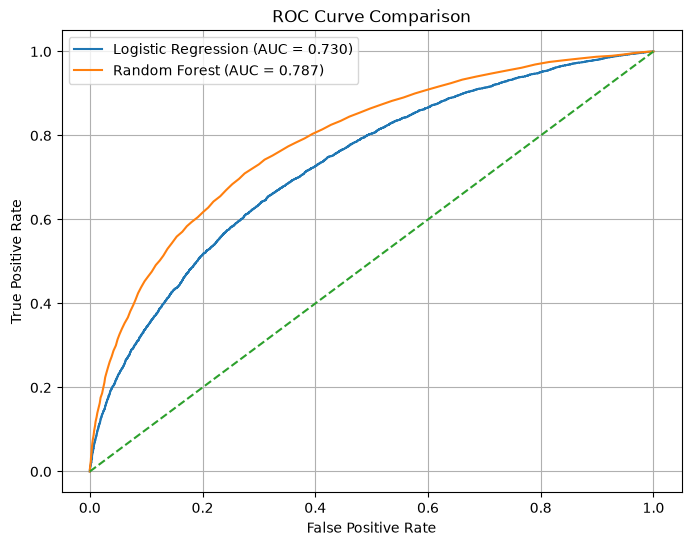

In [476]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

lr_fpr, lr_tpr, lr_thresholds = roc_curve(
    y_test,
    lr_probabilities
)

rf_fpr, rf_tpr, rf_thresholds = roc_curve(
    y_test,
    rf_probabilities
)



plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_roc_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()

plt.show()


Next in our roadmap is feature importance, where we'll answer a very useful question:
Which features are actually influencing the Random Forest's predictions?

Which of our 643 input features does the Random Forest consider important when making predictions?

In [540]:
feature_importances = rf_model.feature_importances_

encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
)

all_feature_names = list(encoded_feature_names) + numerical_features

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": feature_importances
})

feature_importance_df.head()

,feature,importance
0,AIRLINE_AA,0.004852
1,AIRLINE_AS,0.003197
2,AIRLINE_B6,0.003101
3,AIRLINE_DL,0.011115
4,AIRLINE_EV,0.004219


In [ ]:
feature_importance_sorted = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)
feature_importance_df
feature_importance_sorted['feature'] == 'MONTH'

<generator object DataFrame.items at 0x13d5dda80>

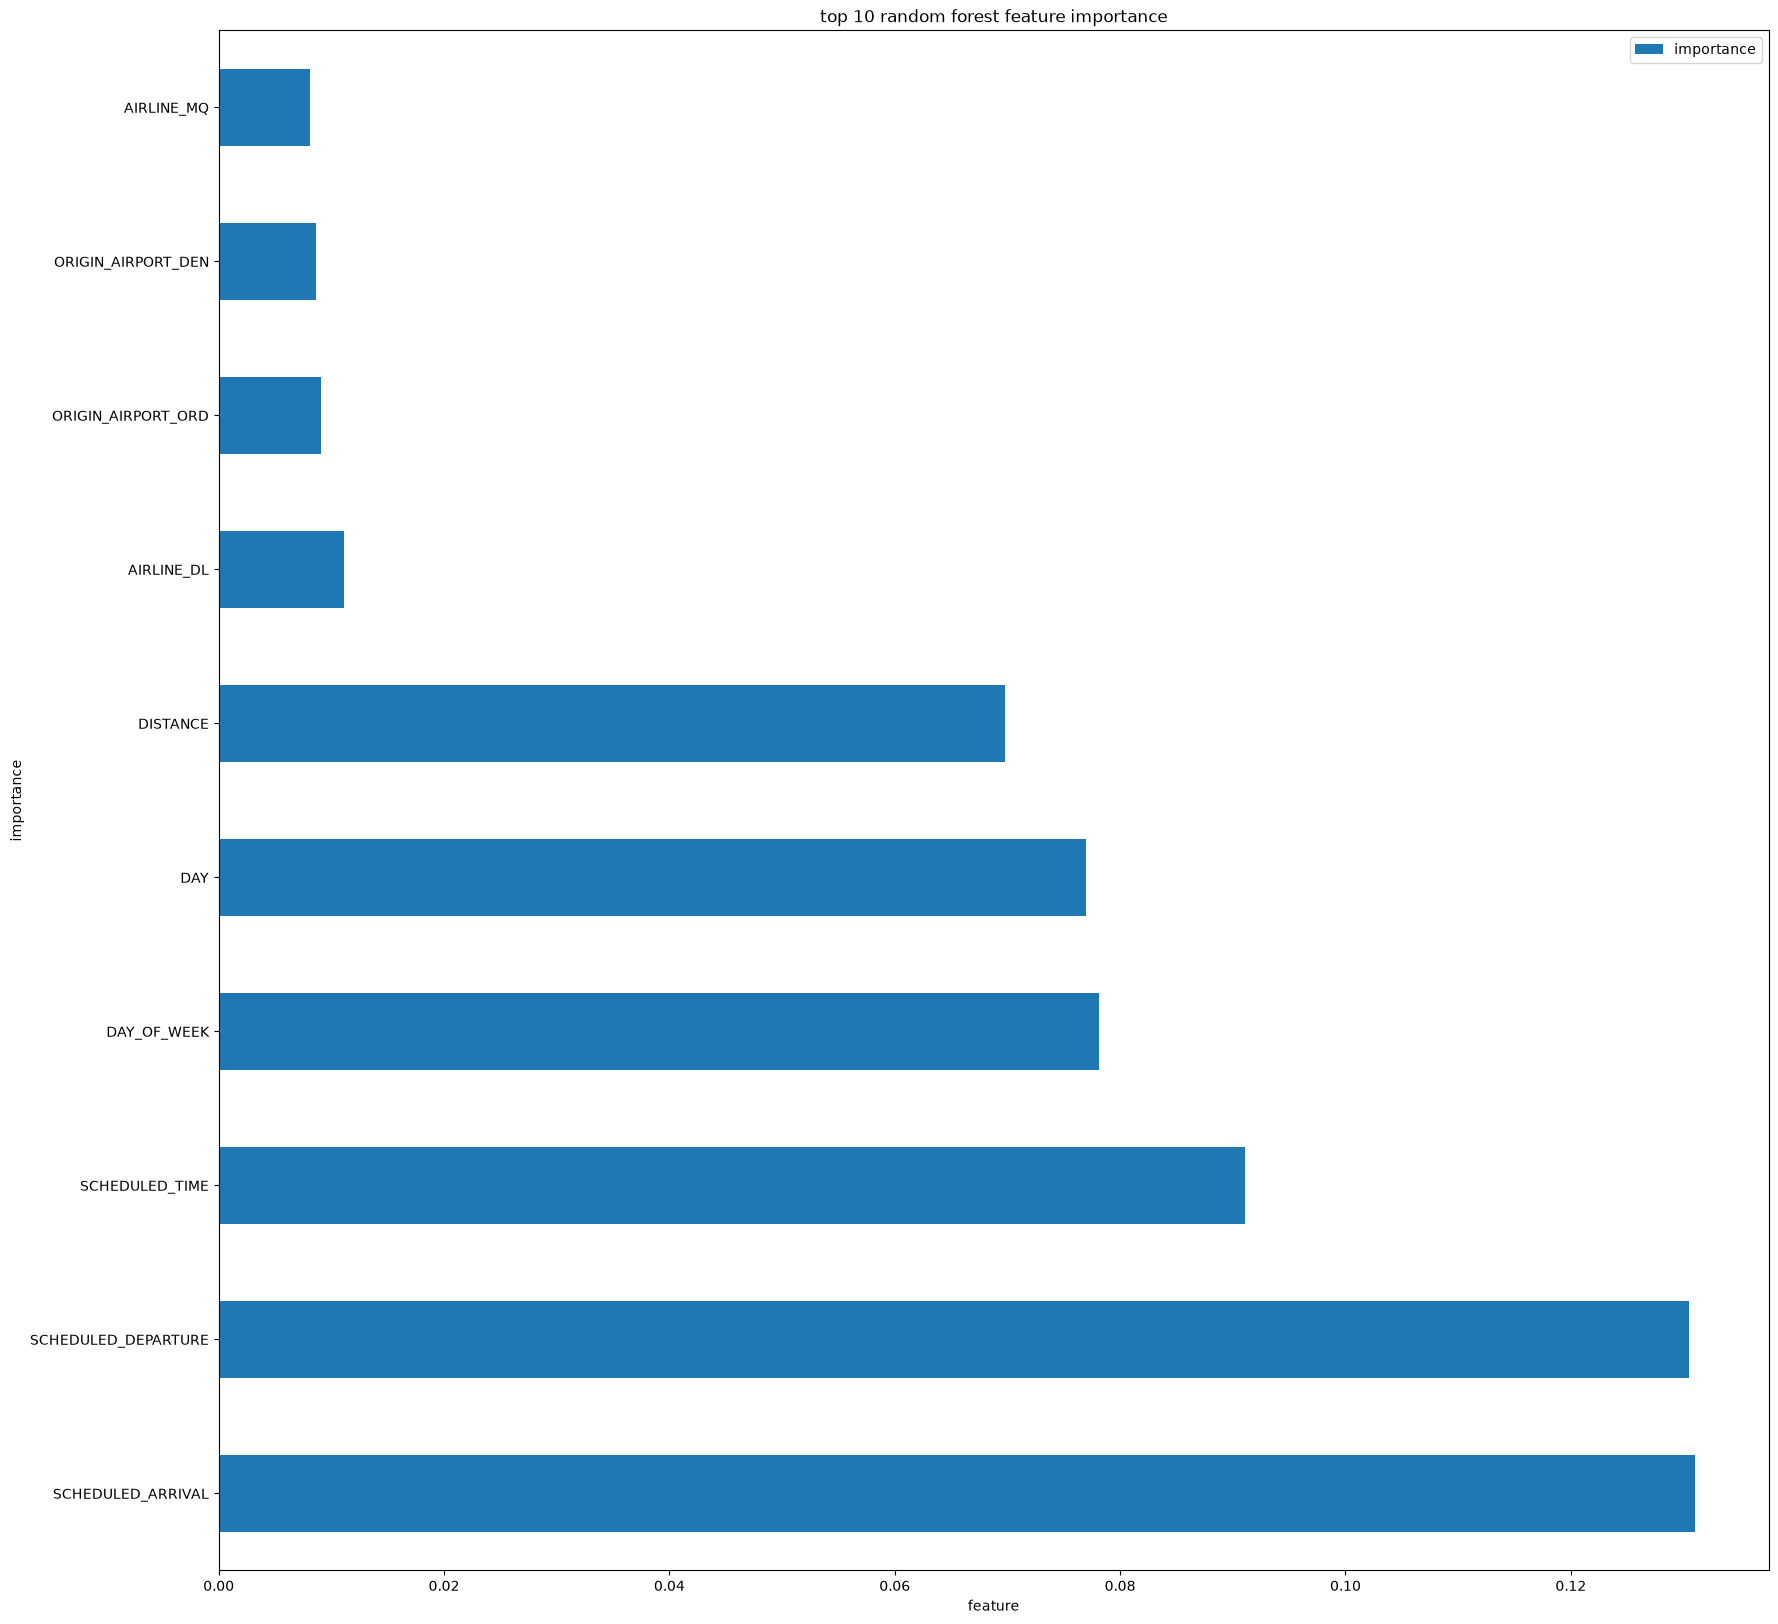

In [ ]:
top_features = feature_importance_sorted.head(10)

top_features.plot(
      x="feature",       # category
    y="importance",    # numeric value
    

    kind = "barh",
    figsize=(20,20)
)

plt.title("top 10 random forest feature importance")
plt.xlabel("feature")
plt.ylabel("importance")
plt.show()

In [ ]:
grouped_importance = {

    "AIRLINE": feature_importance_df[
        feature_importance_df["feature"].str.startswith("AIRLINE_")
    ]["importance"].sum(),

    "ORIGIN_AIRPORT": feature_importance_df[
        feature_importance_df["feature"].str.startswith("ORIGIN_AIRPORT_")
    ]["importance"].sum(),

    "DESTINATION_AIRPORT": feature_importance_df[
        feature_importance_df["feature"].str.startswith("DESTINATION_AIRPORT_")
    ]["importance"].sum()

}



DataFrame[
    condition
]["column"].operation()

In [ ]:
for feature in numerical_features:
    grouped_importance[feature] = feature_importance_df[
        feature_importance_df['feature'] == feature]['importance'].sum()
list(grouped_importance.items())


[('AIRLINE', np.float64(0.064655423105832)),
 ('ORIGIN_AIRPORT', np.float64(0.18444682666313297)),
 ('DESTINATION_AIRPORT', np.float64(0.1733545355996019)),
 ('MONTH', np.float64(0.0)),
 ('DAY', np.float64(0.07700852042848723)),
 ('DAY_OF_WEEK', np.float64(0.07811060349293035)),
 ('SCHEDULED_DEPARTURE', np.float64(0.13052400850669646)),
 ('SCHEDULED_ARRIVAL', np.float64(0.1310085256968056)),
 ('SCHEDULED_TIME', np.float64(0.09107406647077565)),
 ('DISTANCE', np.float64(0.06981749003573798))]

In [ ]:
grouped_importance_df = pd.DataFrame(
    list(grouped_importance.items()),
    columns=['feature','importance']


)
grouped_importance_df = grouped_importance_df.sort_values(
    by='importance',
    ascending=False

)

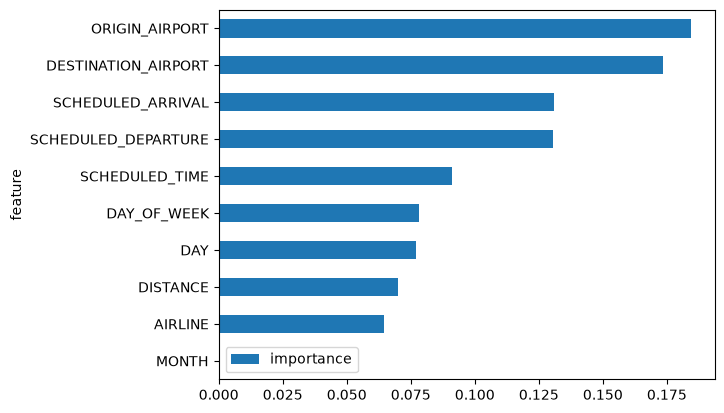

In [578]:
grouped_importance_df.plot(
    kind='barh',
    x = "feature",
    y = 'importance'


)
plt.gca().invert_yaxis()


In [579]:
flights.columns.tolist()

['YEAR',
 'MONTH',
 'DAY',
 'DAY_OF_WEEK',
 'AIRLINE',
 'FLIGHT_NUMBER',
 'TAIL_NUMBER',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'SCHEDULED_DEPARTURE',
 'DEPARTURE_TIME',
 'DEPARTURE_DELAY',
 'TAXI_OUT',
 'WHEELS_OFF',
 'SCHEDULED_TIME',
 'ELAPSED_TIME',
 'AIR_TIME',
 'DISTANCE',
 'WHEELS_ON',
 'TAXI_IN',
 'SCHEDULED_ARRIVAL',
 'ARRIVAL_TIME',
 'ARRIVAL_DELAY',
 'DIVERTED',
 'CANCELLED',
 'CANCELLATION_REASON',
 'AIR_SYSTEM_DELAY',
 'SECURITY_DELAY',
 'AIRLINE_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'WEATHER_DELAY']

In [2]:
import streamlit as st
import joblib
from pathlib import Path
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)
joblib.dump(rf_model ,models_dir / "rf_model.pkl")
joblib.dump(encoder,models_dir / "encoder.pkl")
joblib.dump(scaler,models_dir / "scaler.pkl")

st.title("Flight Delay Prediction")


NameError: name 'rf_model' is not defined